# Data Cleanup and Preparation

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [3]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

On initial analysis, it can be observed that age column has 177 nulls out of 891 rows, which means 19.8% of the data has missing age values. Furthermore, the cabin columb has almost 78% of data missing. The embarked column has only 2 missing values so we can fill that with the most frequent value.


In [5]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [8]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

For missing age values, we can use the median age to replace them. We use the median age as older passengers can pull the mean up, and the median is more robust to outliers.

For the 2 missing embarked values, we can use "S" to replace them as those are the most frequent value, thus we can safely assume that they came from the most common port (Southampton).

Finally, we can drop the cabin column entirely as most of the columns are NULL and cannot be salvaged. Similarly, the name and ticket columns can be dropped as they do not have any relevant meaning to our analysis. 

In [10]:
df['Age'].replace(np.nan,df['Age'].median(),inplace=True)
df['Embarked'].replace(np.nan,df['Embarked'].value_counts().idxmax(),inplace=True)
df.drop('Cabin',axis=1,inplace=True)
df.drop('Name',axis=1,inplace=True)
df.drop('Ticket',axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


/var/folders/b1/yj22wy75115cyfk8k2z1phs40000gn/T/ipykernel_83779/3954686831.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].replace(np.nan,df['Age'].median(),inplace=True)


This concludes the data cleanup. 


# Exploratory Data Analysis

In [31]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [32]:
df.groupby('Sex')['Survived'].value_counts()


Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [33]:
df.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

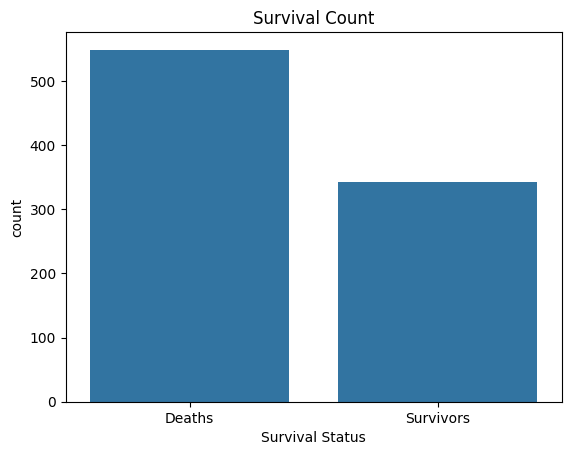

In [34]:
sns.countplot(x='Survived',data=df)
plt.title('Survival Count')
plt.xlabel('Survival Status')
plt.xticks([0,1],['Deaths','Survivors'])
plt.show()

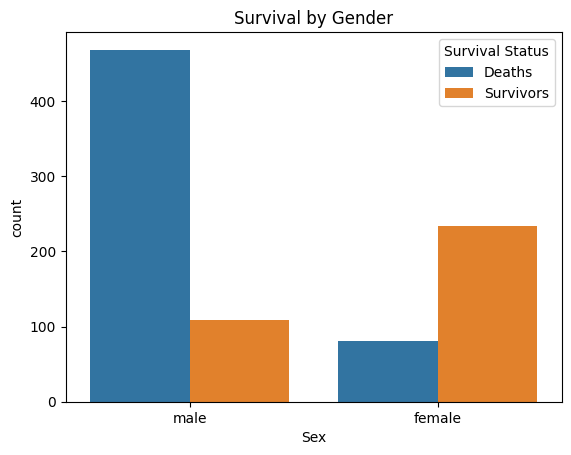

In [35]:
sns.countplot(x='Sex', hue='Survived',data=df)
plt.legend(title='Survival Status', labels=['Deaths','Survivors'])
plt.title('Survival by Gender')
plt.show()

Based on the above plot, we can see that a higher proportion of men died compared to women.

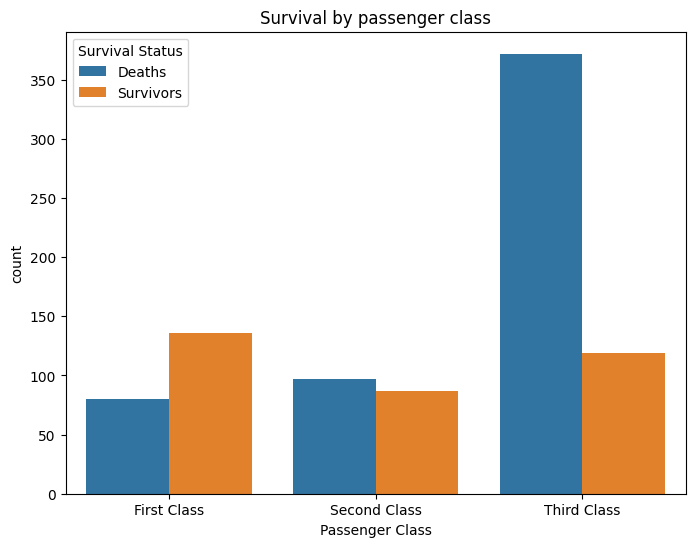

In [36]:
plt.figure(figsize=(8,6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.legend(title='Survival Status', labels=['Deaths','Survivors'])
plt.title('Survival by passenger class')
plt.xlabel('Passenger Class')
plt.xticks([0,1,2], ['First Class','Second Class','Third Class'])
plt.show()

We can see that a higher proportion of third class passengers died compared to first and second class passengers combined, highlighting the socio-economic inequality on board the titanic. 

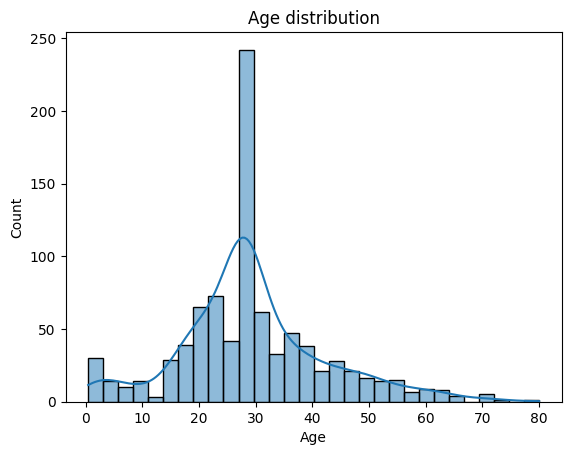

In [37]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age distribution')
plt.show()

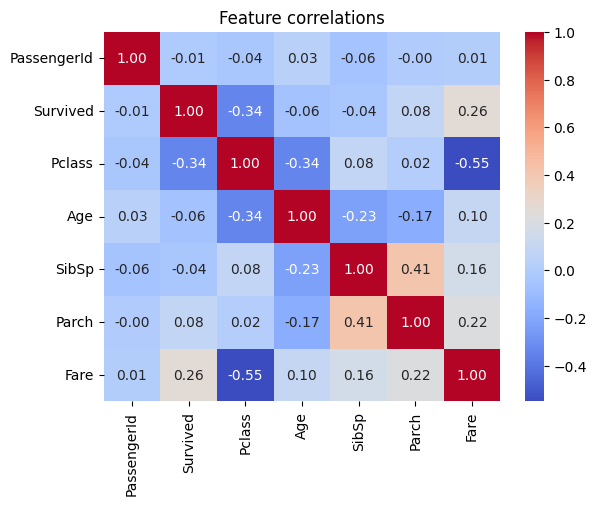

In [38]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlations')
plt.show()

From the heatmap above we can see that the correlation value between Pclass and Survived is -0.34. 
This means that the higher class number means lower class which means lower survival, this confirms the bar chart.

Furthermore, the correlation between Fare and Survived is +0.26, which implies that passenger who paid more survived more as they were in a higher class.

Age does not have much of a correlation with survivors, thus it is weaker than expected.

In [39]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.to_csv('titanic_clean.csv', index=False)